In [124]:
import pandas as pd
import seaborn as sns
from sklearn.metrics import precision_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

In [16]:
df=pd.read_csv('E:/3rd year/2nd term/Interpretability/Dsai 305 Project/_Data/cardio_data_cleaned(IQR).csv')

In [17]:
X=df.drop(columns=['cardio',])
y=df['cardio']

In [18]:
df

,age,gender,cholesterol,gluc,smoke,alco,active,cardio,BMI,MAP
0,3,2,1,1,0,0,1,0,2,2
1,4,1,3,1,0,0,1,1,3,4
2,3,1,3,1,0,0,0,1,2,2
3,2,2,1,1,0,0,1,1,3,5
4,5,1,2,2,0,0,0,0,3,2
...,...,...,...,...,...,...,...,...,...,...
62497,3,1,1,1,0,0,1,1,2,3
62498,4,1,1,1,0,0,1,1,3,3
62499,3,2,1,1,1,0,1,0,2,2
62500,5,1,1,2,0,0,0,1,2,3


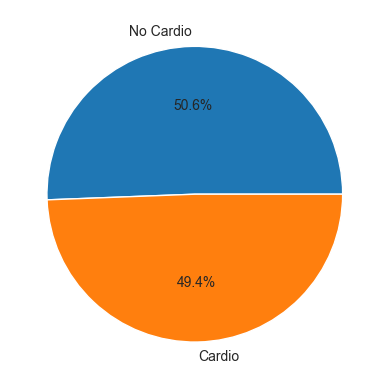

In [42]:
plt.pie(df['cardio'].value_counts(), labels=['No Cardio', 'Cardio'], autopct='%1.1f%%')
plt.show()

In [144]:
from sklearn.feature_selection import f_classif
f_values, p_values = f_classif(X, y)

In [24]:
Anovadf=df

In [25]:
for i in range(len(f_values)):
    if p_values[i] < 0.05:
        print(f"Feature {X.columns[i]} is significant with p-value {p_values[i]}")
    else:
        Anovadf=Anovadf.drop(columns=[X.columns[i]])
        print(f"Feature {X.columns[i]} is not significant with p-value {p_values[i]:}")

Feature age is significant with p-value 0.0000
Feature gender is not significant with p-value 0.2287
Feature cholesterol is significant with p-value 0.0000
Feature gluc is significant with p-value 0.0000
Feature smoke is significant with p-value 0.0000
Feature alco is significant with p-value 0.0021
Feature active is significant with p-value 0.0000
Feature BMI is significant with p-value 0.0000
Feature MAP is significant with p-value 0.0000


In [26]:
Anovadf

,age,cholesterol,gluc,smoke,alco,active,cardio,BMI,MAP
0,3,1,1,0,0,1,0,2,2
1,4,3,1,0,0,1,1,3,4
2,3,3,1,0,0,0,1,2,2
3,2,1,1,0,0,1,1,3,5
4,5,2,2,0,0,0,0,3,2
...,...,...,...,...,...,...,...,...,...
62497,3,1,1,0,0,1,1,2,3
62498,4,1,1,0,0,1,1,3,3
62499,3,1,1,1,0,1,0,2,2
62500,5,1,2,0,0,0,1,2,3


In [28]:
from sklearn.feature_selection import chi2
chi2_scores, p_values = chi2(X, y)

In [43]:
chidf=df

In [44]:
for i in range(len(chi2_scores)):
    if p_values[i] < 0.05:
        print(f"Feature {X.columns[i]} is significant with p-value {p_values[i]:.4f}")
    else:
        chidf=chidf.drop(columns=[X.columns[i]])
        print(f"Feature {X.columns[i]} is not significant with p-value {p_values[i]:.4f}")

Feature age is significant with p-value 0.0000
Feature gender is not significant with p-value 0.6214
Feature cholesterol is significant with p-value 0.0000
Feature gluc is significant with p-value 0.0000
Feature smoke is significant with p-value 0.0000
Feature alco is significant with p-value 0.0027
Feature active is significant with p-value 0.0000
Feature BMI is significant with p-value 0.0000
Feature MAP is significant with p-value 0.0000


In [49]:
from sklearn.feature_selection import mutual_info_classif
mutual_info = mutual_info_classif(X, y)

In [50]:
mutal_info_df=df

In [51]:
for i in range(len(mutual_info)):
    if mutual_info[i] > 0.0:
        print(f"Feature {X.columns[i]} is significant with mutual information {mutual_info[i]:.4f}")
    else:
        mutal_info_df=mutal_info_df.drop(columns=[X.columns[i]])
        print(f"Feature {X.columns[i]} is not significant with mutual information {mutual_info[i]:.4f}")

Feature age is significant with mutual information 0.0307
Feature gender is significant with mutual information 0.0012
Feature cholesterol is significant with mutual information 0.0279
Feature gluc is significant with mutual information 0.0079
Feature smoke is not significant with mutual information 0.0000
Feature alco is significant with mutual information 0.0004
Feature active is significant with mutual information 0.0093
Feature BMI is significant with mutual information 0.0151
Feature MAP is significant with mutual information 0.0966


In [52]:
mutal_info_df

,age,gender,cholesterol,gluc,alco,active,cardio,BMI,MAP
0,3,2,1,1,0,1,0,2,2
1,4,1,3,1,0,1,1,3,4
2,3,1,3,1,0,0,1,2,2
3,2,2,1,1,0,1,1,3,5
4,5,1,2,2,0,0,0,3,2
...,...,...,...,...,...,...,...,...,...
62497,3,1,1,1,0,1,1,2,3
62498,4,1,1,1,0,1,1,3,3
62499,3,2,1,1,0,1,0,2,2
62500,5,1,1,2,0,0,1,2,3


anova and chi are the same df so we will compare between them and mutual info

In [37]:
from sklearn.model_selection import train_test_split

In [53]:
Df1=Anovadf
Df2=mutal_info_df

First Dataframe

In [82]:
X1 = Df1.drop(columns=['cardio'])
y1 = Df1['cardio']

In [83]:
X_train1, X_test1, y_train1, y_test1 = train_test_split(X1, y1, test_size=0.2, random_state=42)

In [84]:
xgb1 = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

In [85]:
xgb1.fit(X_train1, y_train1)

C:\Users\omaar\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:183: UserWarning: [19:30:07] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [86]:
y_pred1 = xgb1.predict(X_test1)

In [87]:
accuracy1 = accuracy_score(y_test1, y_pred1)

In [88]:
print(f"Accuracy: {accuracy1}")

Accuracy: 0.7232221422286217


Second Dataframe

In [89]:
X2= Df2.drop(columns=['cardio'])
y2= Df2['cardio']

In [90]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.2, random_state=42)

In [91]:
xgb2 = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

In [92]:
xgb2.fit(X_train2, y_train2)

C:\Users\omaar\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:183: UserWarning: [19:30:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [94]:
y_pred2 = xgb2.predict(X_test2)

In [96]:
accuracy2 = accuracy_score(y_test2, y_pred2)

In [97]:
print(f"Accuracy: {accuracy2}")

Accuracy: 0.7205023598112151


Since the accuracy of the first dataframe is higher than the second one, we can conclude that the features selected by ANOVA are more significant than those selected by mutual information.
and all the explanations will be done on the first dataframe

In [100]:
from sklearn.metrics import confusion_matrix, f1_score

Sensitivity: 0.6864847303443795, Specificity: 0.7588652482269503, F1 Score: 0.7095366017461383


In [109]:
confusion=confusion_matrix(y_test1, y_pred1)

<Axes: >

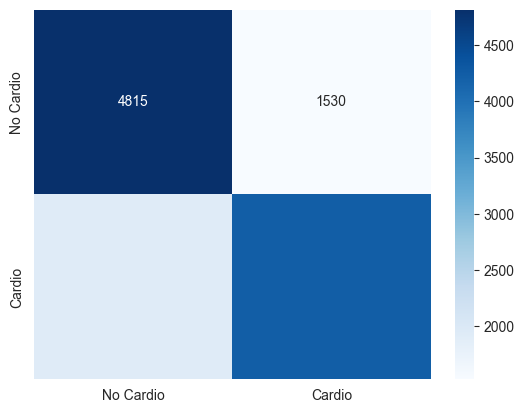

In [115]:
sns.heatmap(confusion, annot=True, fmt='d', cmap='Blues', xticklabels=['No Cardio', 'Cardio'], yticklabels=['No Cardio', 'Cardio'])

In [104]:
tn, fp, fn, tp = confusion_matrix(y_test1, y_pred1).ravel()

In [105]:
sensitivity1= tp / (tp + fn)

In [117]:
specificity1= 1-(fp / (tn + fp))

In [118]:
f1_1 = f1_score(y_test1, y_pred1)

In [ ]:
precision = precision_score(y_test1, y_pred1)

In [ ]:
y_pred_proba = xgb1.predict_proba(X_test1)[:, 1]
auc_score = roc_auc_score(y_test1, y_pred_proba)

In [125]:
print(f"Sensitivity: {sensitivity1}, Specificity: {specificity1}, F1 Score: {f1_1}, Precision: {precision}, AUC Score: {auc_score}")

Sensitivity: 0.6864847303443795, Specificity: 0.7588652482269503, F1 Score: 0.7095366017461383, Precision: 0.7341904100069493, AUC Score: 0.7859503960847746


C:\Users\omaar\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\omaar\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\omaar\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\omaar\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning

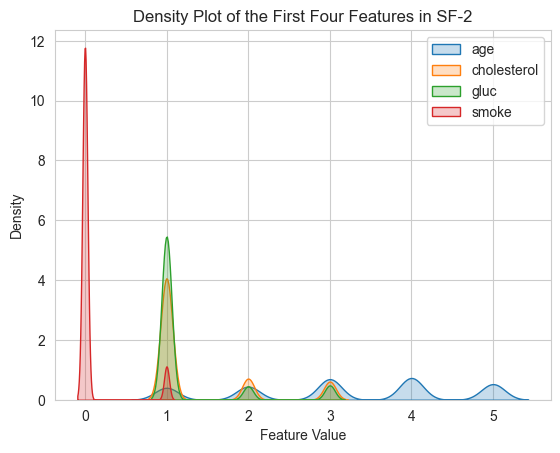

In [188]:
import seaborn as sns
import matplotlib.pyplot as plt
features = Df1.drop(columns=['cardio']).columns[:4]
for feature in features:
    sns.kdeplot(Df1[feature], label=feature, fill=True)
plt.title('Density Plot of the First Four Features in SF-2')
plt.xlabel('Feature Value')
plt.ylabel('Density')
plt.legend()
plt.show()

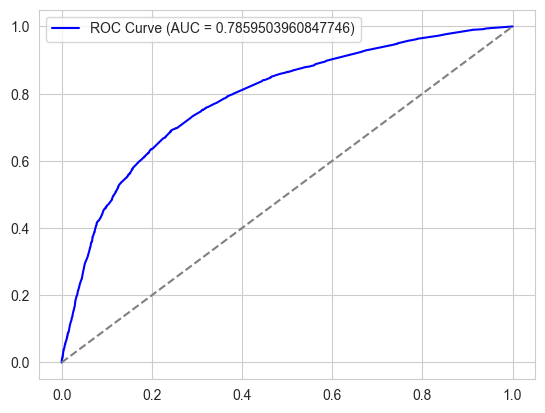

In [129]:
fpr, tpr, thresholds = roc_curve(y_test1, y_pred_proba)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.legend()
plt.show()

In [196]:
import shap

In [201]:
explainer = shap.TreeExplainer(xgb1)
shap_values = explainer.shap_values(X_test1)

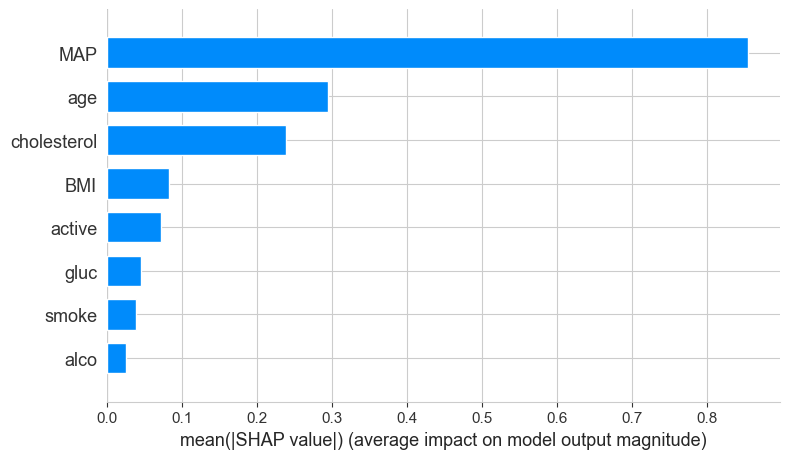

In [202]:
shap.summary_plot(shap_values, X_test1, plot_type="bar")

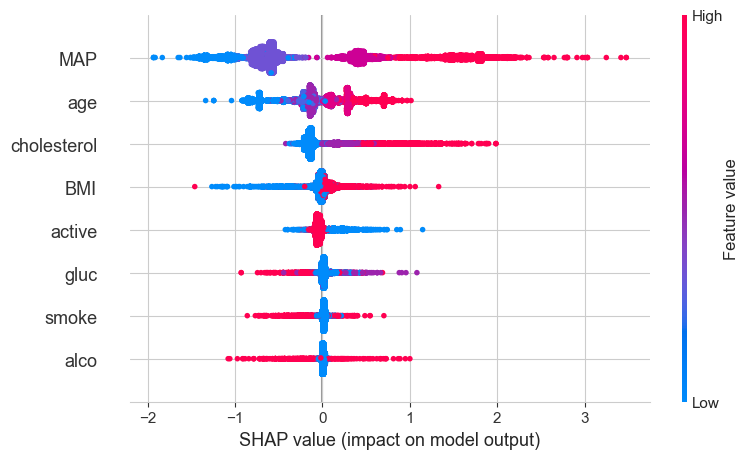

In [204]:
shap.summary_plot(shap_values, X_test1)

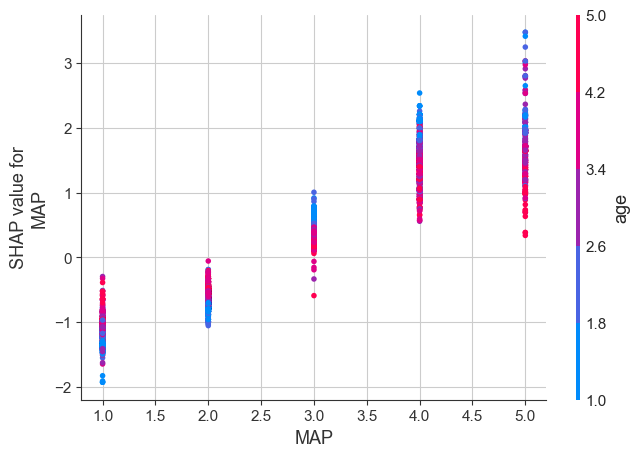

In [205]:
shap.dependence_plot(7, shap_values, X_test1)

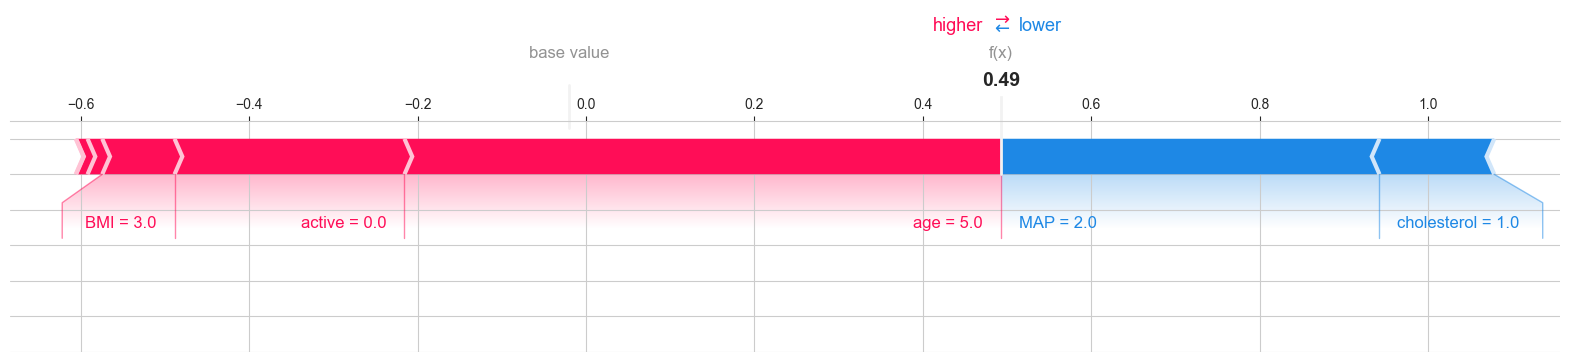

In [206]:
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[0], X_test1.iloc[0], matplotlib=True)

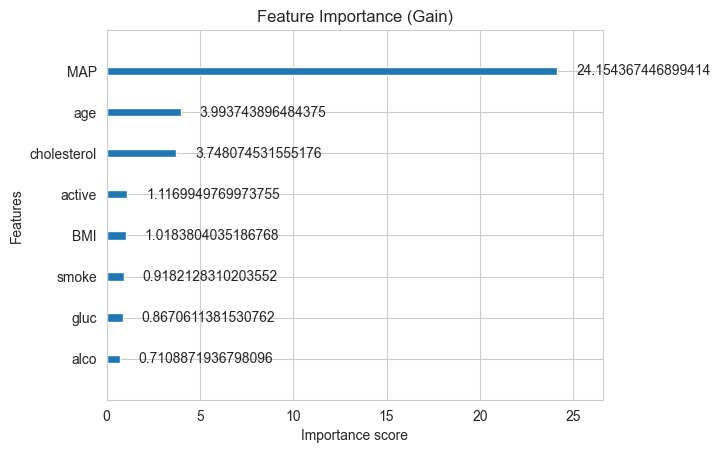

In [166]:
import matplotlib.pyplot as plt
from xgboost import plot_importance
plot_importance(xgb1, importance_type='gain', max_num_features=10, title="Feature Importance (Gain)")
plt.show()


In [176]:
Df1

,age,cholesterol,gluc,smoke,alco,active,cardio,BMI,MAP
0,3,1,1,0,0,1,0,2,2
1,4,3,1,0,0,1,1,3,4
2,3,3,1,0,0,0,1,2,2
3,2,1,1,0,0,1,1,3,5
4,5,2,2,0,0,0,0,3,2
...,...,...,...,...,...,...,...,...,...
62497,3,1,1,0,0,1,1,2,3
62498,4,1,1,0,0,1,1,3,3
62499,3,1,1,1,0,1,0,2,2
62500,5,1,2,0,0,0,1,2,3


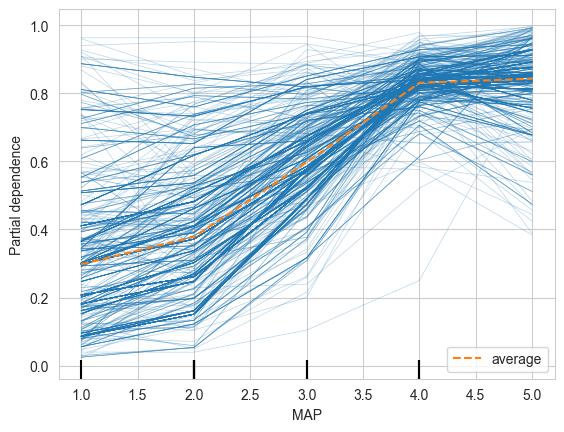

In [180]:
from sklearn.inspection import PartialDependenceDisplay
feature = [7]
target_class = 1
PartialDependenceDisplay.from_estimator(xgb1, X_test1, features=feature, target=target_class,kind='both')
plt.show()

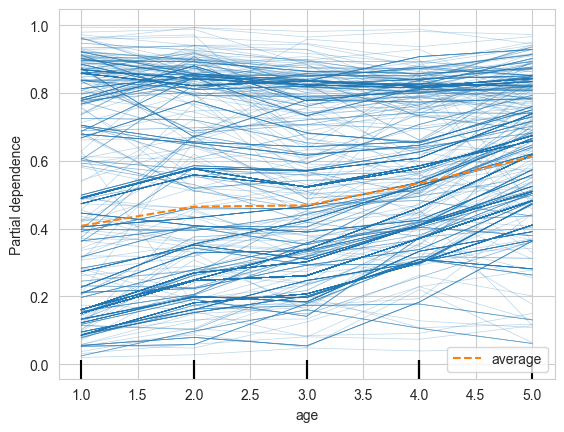

In [181]:
from sklearn.inspection import PartialDependenceDisplay
feature = [0]
target_class = 1
PartialDependenceDisplay.from_estimator(xgb1, X_test1, features=feature, target=target_class,kind='both')
plt.show()

In [182]:
import lime
import lime.lime_tabular
explainer = lime.lime_tabular.LimeTabularExplainer(X_train1.values, feature_names=X_train1.columns, class_names=['No Cardio', 'Cardio'], mode='classification')

In [184]:
random_sample_index = 0
random_sample = X_test1.iloc[random_sample_index]
explanation = explainer.explain_instance(random_sample.values, xgb1.predict_proba, num_features=10)

In [186]:
explanation.show_in_notebook(show_table=True, show_all=False)

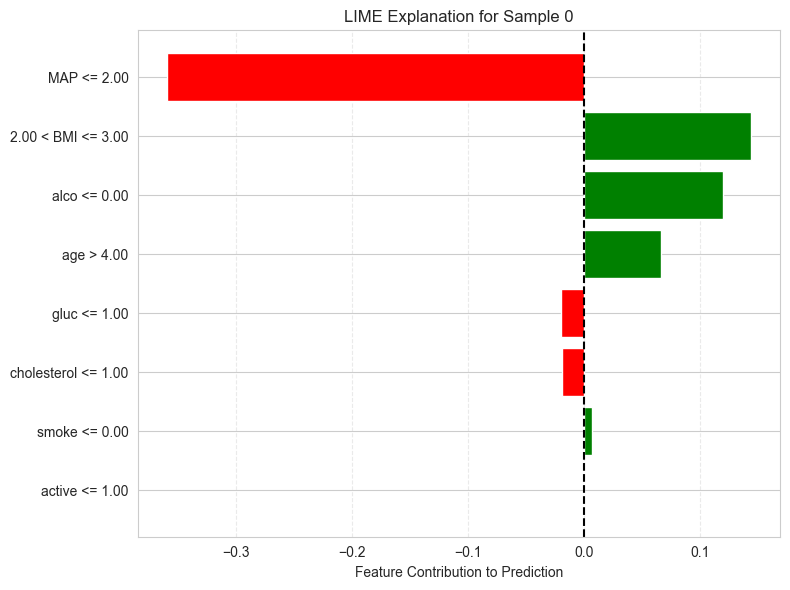

In [187]:
exp_list = explanation.as_list(label=1)[::-1]  
features = [item[0] for item in exp_list]
weights = [item[1] for item in exp_list]
plt.figure(figsize=(8, 6))
bars = plt.barh(features, weights, color=['green' if w > 0 else 'red' for w in weights])
plt.axvline(x=0, color='black', linestyle='--')
plt.xlabel("Feature Contribution to Prediction")
plt.title(f"LIME Explanation for Sample {random_sample_index}", loc='center')
plt.tight_layout()
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.show()